# DDPM from Scratch — Fashion-MNIST

A minimal, first-principles implementation of Denoising Diffusion Probabilistic Models (Ho et al., 2020), built to make every piece of the math visible and checkable — not to chase state-of-the-art sample quality.

**Structure:**
1. Forward (noising) process — closed form + verification against step-by-step simulation
2. Visualize the noising schedule
3. Small U-Net with sinusoidal timestep embedding
4. Training with the simplified loss $L_{simple} = \mathbb{E}[\|\epsilon - \epsilon_\theta(x_t, t)\|^2]$, loss logged per noise-level bucket
5. Ancestral sampling (reverse process)
6. DDIM sampling (deterministic, fewer steps) — extension

Runs on a Colab T4. Uses Fashion-MNIST (28x28 grayscale) so training is fast enough to actually iterate.


In [ ]:
!pip install -q torch torchvision matplotlib tqdm

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
from torchvision import transforms
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

torch.manual_seed(0)
np.random.seed(0)

Using device: cpu


## 1. Forward process

$$q(x_t \mid x_{t-1}) = \mathcal{N}(x_t;\ \sqrt{1-\beta_t}\, x_{t-1},\ \beta_t I)$$

With $\alpha_t = 1-\beta_t$ and $\bar\alpha_t = \prod_{s=1}^t \alpha_s$, this collapses to a closed form so we can jump straight from $x_0$ to any $x_t$:

$$q(x_t \mid x_0) = \mathcal{N}(x_t;\ \sqrt{\bar\alpha_t}\, x_0,\ (1-\bar\alpha_t) I)
\quad\Longrightarrow\quad
x_t = \sqrt{\bar\alpha_t}\, x_0 + \sqrt{1-\bar\alpha_t}\,\epsilon,\quad \epsilon\sim\mathcal{N}(0,I)$$

We verify this closed form against an actual step-by-step simulation before trusting it — a schedule bug here silently wrecks everything downstream.

In [ ]:
T = 1000
beta = torch.linspace(1e-4, 0.02, T)
alpha = 1.0 - beta
alpha_bar = torch.cumprod(alpha, dim=0)

# sanity print at a few checkpoints
for t in [1, 100, 500, 1000]:
    ab = alpha_bar[t-1]
    print(f"t={t:4d}  alpha_bar={ab:.6f}  sqrt(alpha_bar)={ab.sqrt():.4f}  sqrt(1-alpha_bar)={(1-ab).sqrt():.4f}")

t=   1  alpha_bar=0.999900  sqrt(alpha_bar)=0.9999  sqrt(1-alpha_bar)=0.0100
t= 100  alpha_bar=0.897018  sqrt(alpha_bar)=0.9471  sqrt(1-alpha_bar)=0.3209
t= 500  alpha_bar=0.078587  sqrt(alpha_bar)=0.2803  sqrt(1-alpha_bar)=0.9599
t=1000  alpha_bar=0.000040  sqrt(alpha_bar)=0.0064  sqrt(1-alpha_bar)=1.0000


In [ ]:
# Verify closed-form q(x_t | x0) against step-by-step simulation, on random scalar data.
def verify_closed_form(t_check=250, n_samples=100_000, seed=1):
    x0 = torch.randn(n_samples)

    torch.manual_seed(seed)
    x = x0.clone()
    for t in range(t_check):
        eps = torch.randn_like(x)
        x = alpha[t].sqrt() * x + beta[t].sqrt() * eps

    torch.manual_seed(seed)
    eps_direct = torch.randn_like(x0)
    x_direct = alpha_bar[t_check-1].sqrt() * x0 + (1 - alpha_bar[t_check-1]).sqrt() * eps_direct

    print(f"step-by-step   mean={x.mean():.4f} std={x.std():.4f}")
    print(f"closed-form    mean={x_direct.mean():.4f} std={x_direct.std():.4f}")
    print("(same seed at each noise draw -> should match almost exactly)")

verify_closed_form()

step-by-step   mean=-0.0024 std=1.0010
closed-form    mean=-0.0030 std=1.0009
(same seed at each noise draw -> should match almost exactly)


In [ ]:
def q_sample(x0, t, noise=None):
    """Sample x_t ~ q(x_t | x0) using the closed form. t: LongTensor of shape (batch,)"""
    if noise is None:
        noise = torch.randn_like(x0)
    sqrt_ab = alpha_bar[t].sqrt().view(-1, 1, 1, 1)
    sqrt_one_minus_ab = (1 - alpha_bar[t]).sqrt().view(-1, 1, 1, 1)
    return sqrt_ab * x0 + sqrt_one_minus_ab * noise, noise

## 2. Data + visualize the noising schedule

Before training anything, look at what the forward process actually does to a real image across $t$. This is the single fastest way to catch a broken schedule.

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),                # [0,1]
    transforms.Lambda(lambda x: x * 2 - 1)  # scale to [-1, 1], standard for diffusion
])

train_ds = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=2, drop_last=True)

print(f"Dataset size: {len(train_ds)}")

100%|██████████| 26.4M/26.4M [00:02<00:00, 8.99MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 139kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.60MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 21.9MB/s]

Dataset size: 60000


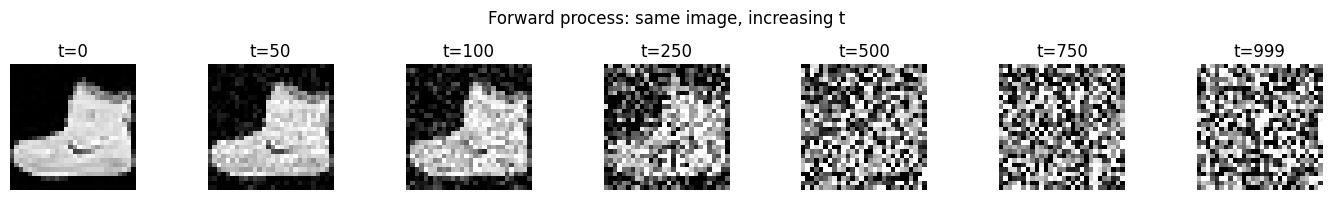

In [ ]:
x0_example, _ = train_ds[0]
x0_example = x0_example.unsqueeze(0)  # (1, 1, 28, 28)

ts_to_show = [0, 50, 100, 250, 500, 750, 999]
fig, axes = plt.subplots(1, len(ts_to_show), figsize=(2*len(ts_to_show), 2))
torch.manual_seed(42)
for ax, t in zip(axes, ts_to_show):
    t_tensor = torch.tensor([t])
    xt, _ = q_sample(x0_example, t_tensor)
    img = (xt[0, 0].clamp(-1, 1) + 1) / 2  # back to [0,1] for display
    ax.imshow(img, cmap='gray')
    ax.set_title(f't={t}')
    ax.axis('off')
plt.suptitle('Forward process: same image, increasing t')
plt.tight_layout()
plt.show()

## 3. Model: small U-Net with sinusoidal timestep embedding

The network's only job: given a noisy image $x_t$ and the timestep $t$, predict the noise $\epsilon$ that was added. The timestep is injected into every residual block via a sinusoidal embedding (same idea as Transformer positional encodings) passed through a small MLP.

In [ ]:
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half_dim = self.dim // 2
        freqs = torch.exp(
            -np.log(10000) * torch.arange(half_dim, device=t.device).float() / (half_dim - 1)
        )
        args = t.float()[:, None] * freqs[None, :]
        return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)


class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        self.time_mlp = nn.Linear(time_dim, out_ch)
        self.block1 = nn.Sequential(nn.GroupNorm(8, in_ch), nn.SiLU(), nn.Conv2d(in_ch, out_ch, 3, padding=1))
        self.block2 = nn.Sequential(nn.GroupNorm(8, out_ch), nn.SiLU(), nn.Conv2d(out_ch, out_ch, 3, padding=1))
        self.res_conv = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = self.block1(x)
        h = h + self.time_mlp(t_emb)[:, :, None, None]
        h = self.block2(h)
        return h + self.res_conv(x)


class SelfAttention(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.norm = nn.GroupNorm(8, ch)
        self.qkv = nn.Conv2d(ch, ch * 3, 1)
        self.proj = nn.Conv2d(ch, ch, 1)

    def forward(self, x):
        b, c, h, w = x.shape
        qkv = self.qkv(self.norm(x)).reshape(b, 3, c, h * w).permute(1, 0, 3, 2)
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = torch.softmax(q @ k.transpose(-1, -2) / (c ** 0.5), dim=-1)
        out = (attn @ v).permute(0, 2, 1).reshape(b, c, h, w)
        return x + self.proj(out)


class SmallUNet(nn.Module):
    def __init__(self, in_ch=1, base_ch=64, time_dim=256):
        super().__init__()
        self.time_embed = nn.Sequential(
            SinusoidalTimeEmbedding(time_dim),
            nn.Linear(time_dim, time_dim), nn.SiLU(),
            nn.Linear(time_dim, time_dim)
        )

        self.in_conv = nn.Conv2d(in_ch, base_ch, 3, padding=1)

        # Down
        self.down1 = ResBlock(base_ch, base_ch, time_dim)
        self.down2 = ResBlock(base_ch, base_ch * 2, time_dim)
        self.pool = nn.AvgPool2d(2)

        # Bottleneck (with attention — lowest resolution)
        self.mid1 = ResBlock(base_ch * 2, base_ch * 2, time_dim)
        self.mid_attn = SelfAttention(base_ch * 2)
        self.mid2 = ResBlock(base_ch * 2, base_ch * 2, time_dim)

        # Up
        self.up_conv = nn.ConvTranspose2d(base_ch * 2, base_ch * 2, 2, stride=2)
        self.up1 = ResBlock(base_ch * 2 + base_ch * 2, base_ch * 2, time_dim)
        self.up2 = ResBlock(base_ch * 2 + base_ch, base_ch, time_dim)

        self.out_norm = nn.GroupNorm(8, base_ch)
        self.out_conv = nn.Conv2d(base_ch, in_ch, 3, padding=1)

    def forward(self, x, t):
        t_emb = self.time_embed(t)

        x0 = self.in_conv(x)
        d1 = self.down1(x0, t_emb)               # 28x28, base_ch
        d1_pooled = self.pool(d1)                 # 14x14
        d2 = self.down2(d1_pooled, t_emb)         # 14x14, base_ch*2
        d2_pooled = self.pool(d2)                 # 7x7

        m = self.mid1(d2_pooled, t_emb)
        m = self.mid_attn(m)
        m = self.mid2(m, t_emb)

        u = self.up_conv(m)                       # 14x14
        # pad if odd dims mismatch (28 -> 14 -> 7 -> 14 is exact for FashionMNIST after center-cropping to 28; guard anyway)
        if u.shape[-1] != d2.shape[-1]:
            u = F.interpolate(u, size=d2.shape[-2:])
        u = self.up1(torch.cat([u, d2], dim=1), t_emb)

        u = F.interpolate(u, size=d1.shape[-2:], mode='nearest')
        u = self.up2(torch.cat([u, d1], dim=1), t_emb)

        return self.out_conv(F.silu(self.out_norm(u)))

In [ ]:
model = SmallUNet().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {n_params:,}")

# quick shape sanity check
with torch.no_grad():
    test_x = torch.randn(4, 1, 28, 28).to(device)
    test_t = torch.randint(0, T, (4,)).to(device)
    test_out = model(test_x, test_t)
    print(f"Input shape:  {test_x.shape}")
    print(f"Output shape: {test_out.shape}")
    assert test_out.shape == test_x.shape, "Output shape must match input shape (predicting noise)"
    print("Shapes match.")

Model parameters: 1,961,729
Input shape:  torch.Size([4, 1, 28, 28])
Output shape: torch.Size([4, 1, 28, 28])
Shapes match.


## 4. Training

Loss: $L_{simple} = \mathbb{E}_{t, x_0, \epsilon}\left[\|\epsilon - \epsilon_\theta(x_t, t)\|^2\right]$

At each step: sample a batch of real images, sample a random $t$ per image, produce $x_t$ via `q_sample`, ask the network to predict the noise, backprop MSE.

We also track loss **per timestep bucket** (low-$t$/near-clean vs high-$t$/near-pure-noise) — a model that's only good at one regime is a common failure mode worth catching early rather than only looking at the aggregate loss.

In [ ]:
alpha = alpha.to(device)
alpha_bar = alpha_bar.to(device)
beta_dev = beta.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4)
n_epochs = 15  # bump this up if you have time budget; ~15 epochs gives recognizable samples on FashionMNIST

loss_history = []
bucket_loss_history = {b: [] for b in ['low_t (0-333)', 'mid_t (333-666)', 'high_t (666-999)']}

def bucket_for_t(t_val):
    if t_val < T // 3:
        return 'low_t (0-333)'
    elif t_val < 2 * T // 3:
        return 'mid_t (333-666)'
    return 'high_t (666-999)'

for epoch in range(n_epochs):
    epoch_losses = []
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{n_epochs}")
    for x0, _ in pbar:
        x0 = x0.to(device)
        b = x0.shape[0]

        t = torch.randint(0, T, (b,), device=device)
        sqrt_ab = alpha_bar[t].sqrt().view(-1, 1, 1, 1)
        sqrt_one_minus_ab = (1 - alpha_bar[t]).sqrt().view(-1, 1, 1, 1)
        noise = torch.randn_like(x0)
        xt = sqrt_ab * x0 + sqrt_one_minus_ab * noise

        pred_noise = model(xt, t)
        loss = F.mse_loss(pred_noise, noise, reduction='none').mean(dim=[1, 2, 3])  # per-sample, for bucketing

        # log per-bucket loss occasionally (cheap, informative)
        with torch.no_grad():
            for tv, lv in zip(t.tolist()[:8], loss.tolist()[:8]):  # sample a few per batch to keep it cheap
                bucket_loss_history[bucket_for_t(tv)].append(lv)

        loss = loss.mean()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_losses.append(loss.item())
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    loss_history.append(np.mean(epoch_losses))
    print(f"Epoch {epoch+1}: avg loss = {loss_history[-1]:.4f}")

Epoch 1/15:   0%|          | 0/468 [00:00<?, ?it/s]

Epoch 1: avg loss = 0.0863


Epoch 2/15:   0%|          | 0/468 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a0120c5fa60>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a0120c5fa60>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Epoch 2: avg loss = 0.0519


...

Epoch 9/15:   0%|          | 0/468 [00:00<?, ?it/s]

Epoch 9: avg loss = 0.0410


Epoch 10/15:   0%|          | 0/468 [00:00<?, ?it/s]

Epoch 10: avg loss = 0.0411


Epoch 11/15:   0%|          | 0/468 [00:00<?, ?it/s]

NameError: name 'loss_history' is not defined

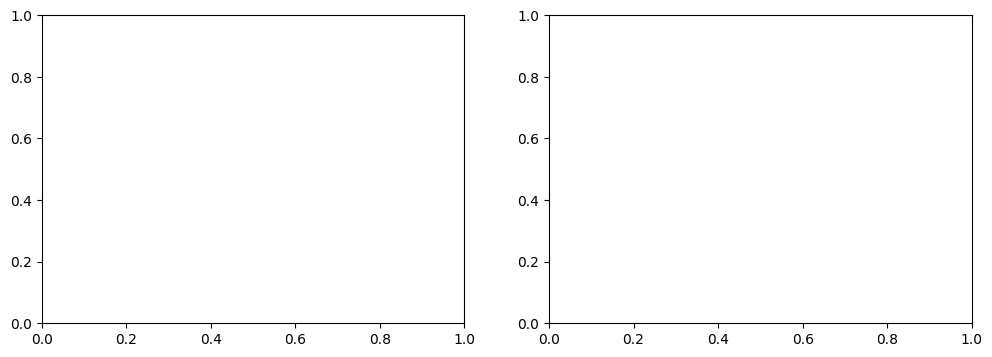

In [2]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(loss_history)
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('avg loss'); axes[0].set_title('Overall training loss')

window = 200
for name, vals in bucket_loss_history.items():
    if len(vals) > window:
        smoothed = np.convolve(vals, np.ones(window)/window, mode='valid')
        axes[1].plot(smoothed, label=name)
axes[1].set_xlabel('logged step (subsampled)'); axes[1].set_ylabel('loss (smoothed)')
axes[1].set_title('Loss by noise-level bucket'); axes[1].legend()

plt.tight_layout()
plt.show()

print("If high_t loss stays much higher than low_t loss, the model struggles most on near-pure-noise inputs,")
print("which tends to hurt early sampling steps (large-scale structure). The reverse pattern hurts fine detail.")

## 5. Sampling — ancestral (standard DDPM reverse process)

Start from pure noise $x_T \sim \mathcal{N}(0,I)$ and iterate:

$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}}\left(x_t - \frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\epsilon_\theta(x_t,t)\right) + \sigma_t z,\quad z\sim\mathcal{N}(0,I)\ \text{if } t>1\ \text{else } 0$$

$\sigma_t^2 = \beta_t$ here (the simple choice from the original paper; the tighter posterior variance $\tilde\beta_t = \frac{1-\bar\alpha_{t-1}}{1-\bar\alpha_t}\beta_t$ is worth trying as an exercise — derive it from $q(x_{t-1}\mid x_t, x_0)$ via Bayes' rule).

In [ ]:
@torch.no_grad()
def sample_ddpm(model, n_samples=16, img_size=28, channels=1):
    model.eval()
    x = torch.randn(n_samples, channels, img_size, img_size, device=device)

    for t_val in tqdm(reversed(range(T)), total=T, desc="sampling"):
        t = torch.full((n_samples,), t_val, device=device, dtype=torch.long)
        pred_noise = model(x, t)

        alpha_t = alpha[t_val]
        alpha_bar_t = alpha_bar[t_val]
        beta_t = beta_dev[t_val]

        coef = beta_t / (1 - alpha_bar_t).sqrt()
        mean = (1 / alpha_t.sqrt()) * (x - coef * pred_noise)

        if t_val > 0:
            z = torch.randn_like(x)
            sigma_t = beta_t.sqrt()
            x = mean + sigma_t * z
        else:
            x = mean

    model.train()
    return x

In [ ]:
samples = sample_ddpm(model, n_samples=16)
samples_display = (samples.clamp(-1, 1) + 1) / 2  # back to [0,1]

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(samples_display[i, 0].cpu(), cmap='gray')
    ax.axis('off')
plt.suptitle('DDPM samples (ancestral sampling, T=1000 steps)')
plt.tight_layout()
plt.show()

## 6. Extension: DDIM sampling

DDIM (Song et al., 2021) reinterprets the same trained model with a **non-Markovian** reverse process that's deterministic (no noise injection) and lets you skip steps — e.g. 50 steps instead of 1000 — while reusing the exact same $\epsilon_\theta$ you already trained.

Update rule (deterministic, $\eta=0$):

$$x_{t-1} = \sqrt{\bar\alpha_{t-1}}\, \underbrace{\left(\frac{x_t - \sqrt{1-\bar\alpha_t}\,\epsilon_\theta(x_t,t)}{\sqrt{\bar\alpha_t}}\right)}_{\text{predicted } x_0} + \sqrt{1-\bar\alpha_{t-1}}\,\epsilon_\theta(x_t,t)$$

Note this makes the "predict $x_0$, then re-noise to the target step" structure explicit — worth comparing directly against the ancestral update above to see how the same $\epsilon_\theta$ gets reused differently.

In [ ]:
@torch.no_grad()
def sample_ddim(model, n_samples=16, n_steps=50, img_size=28, channels=1):
    model.eval()
    x = torch.randn(n_samples, channels, img_size, img_size, device=device)

    # choose a subsequence of timesteps
    step_indices = torch.linspace(0, T - 1, n_steps).long().flip(0)  # descending

    for i in tqdm(range(len(step_indices)), desc="DDIM sampling"):
        t_val = step_indices[i].item()
        t_prev_val = step_indices[i + 1].item() if i + 1 < len(step_indices) else -1

        t = torch.full((n_samples,), t_val, device=device, dtype=torch.long)
        pred_noise = model(x, t)

        ab_t = alpha_bar[t_val]
        ab_prev = alpha_bar[t_prev_val] if t_prev_val >= 0 else torch.tensor(1.0, device=device)

        pred_x0 = (x - (1 - ab_t).sqrt() * pred_noise) / ab_t.sqrt()
        x = ab_prev.sqrt() * pred_x0 + (1 - ab_prev).sqrt() * pred_noise

    model.train()
    return x

In [ ]:
samples_ddim = sample_ddim(model, n_samples=16, n_steps=50)
samples_ddim_display = (samples_ddim.clamp(-1, 1) + 1) / 2

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(samples_ddim_display[i, 0].cpu(), cmap='gray')
    ax.axis('off')
plt.suptitle('DDIM samples (50 steps, same trained model)')
plt.tight_layout()
plt.show()

print("Compare against the 1000-step ancestral samples above: DDIM should be ~20x faster")
print("with broadly comparable quality, since it reuses the same trained epsilon_theta.")